# Creating an NDVI Raster for Enschede, the Netherlands

In [1]:
import fiona
import geopandas as gpd
from pystac_client import Client

import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
import math

## Creating the Enschede GeoDataFrame
### Inspecting the Dutch Municipalities GeoDataFrame

In [2]:
data_folder = '../data'
fiona.listlayers(f'{data_folder}/vectors/nederland_admin_areas.gpkg')

['country', 'provinces', 'cities']

In [3]:
cities = gpd.read_file(f'{data_folder}/vectors/nederland_admin_areas.gpkg', layer='cities')
cities.shape

(342, 6)

In [4]:
print(cities.crs)

EPSG:28992


In [5]:
cities = cities.to_crs('EPSG:4326')
cities.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
0,GM0263,Maasdriel,0263,25,Gelderland,"MULTIPOLYGON (((5.26613 51.7393, 5.26559 51.73..."


### Fitering the Enschede Municipality

In [6]:
enschede = cities[cities['naam']=='Enschede']
enschede.shape

(1, 6)

In [7]:
enschede.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
82,GM0153,Enschede,0153,23,Overijssel,"MULTIPOLYGON (((6.80561 52.16662, 6.80558 52.1..."


## Retrieving Sentinel-2 Data
### Connecting to Element 84's Earth Search API

In [8]:
client = Client.open('https://earth-search.aws.element84.com/v1')
collections = client.get_collections()

for collection in collections:
    print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


### Creating the Search Query

In [9]:
results = client.search(
    collections=['sentinel-2-l2a'],
    intersects=enschede['geometry'].iloc[0],
    datetime='2024-01-01/2024-12-31',
    query=['eo:cloud_cover<25'],
)
items = results.item_collection()

print(f'Found {len(items)} items.')

Found 52 items.


### Creating a GeoDataFrame

In [10]:
images = gpd.GeoDataFrame.from_features(items, crs='EPSG:4326')
images.shape

(52, 42)

In [11]:
images['id'] = [item.id for item in items]
images['id'].head(1)

0    S2B_32ULC_20241130_0_L2A
Name: id, dtype: object

### Filtering for Images Covering Enschede

In [12]:
images = images[images['geometry'].covers(enschede['geometry'].iloc[0])]
images.shape

(7, 43)

### Sorting by Cloud Cover

In [13]:
images = images.sort_values('eo:cloud_cover')
images['eo:cloud_cover'].value_counts()

eo:cloud_cover
0.659834     1
1.092485     1
1.843504     1
8.909372     1
10.827844    1
19.588177    1
23.026903    1
Name: count, dtype: int64

### Mapping the GeoDataFrame to The Items

In [14]:
items_dict = {item.id: item for item in items}
images['item'] = images['id'].map(items_dict)

images['item'].head(1)

48    <Item id=S2A_32ULC_20240127_0_L2A>
Name: item, dtype: object

### Selecting a Single Item

In [15]:
item = images['item'].iloc[0]
item

<Item id=S2A_32ULC_20240127_0_L2A>

### Visualising Item Extents

In [16]:
gpd.GeoDataFrame.from_features([item], crs='EPSG:4326').explore()

## Creating the NDVI Raster
### Stacking the Bands

In [17]:
assets = item.assets

red = rxr.open_rasterio(assets['red'].href).squeeze('band', drop=True)
nir = rxr.open_rasterio(assets['nir'].href).squeeze('band', drop=True)

rgb = xr.concat([red, nir], dim='band')
rgb = rgb.assign_coords(band=['red', 'nir'])
rgb.coords

Coordinates:
  * x            (x) float64 88kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
  * y            (y) float64 88kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
    spatial_ref  int64 8B 0
  * band         (band) <U3 24B 'red' 'nir'

### Calculating NDVI

In [18]:
red = rgb.sel(band='red')
nir = rgb.sel(band='nir')

ndvi = (nir - red) / (nir + red)

In [19]:
print(ndvi.rio.crs)
print(enschede.crs)

EPSG:32632
EPSG:4326


### Reprojecting the Raster and the Vector Mask Layer

In [20]:
ndvi = ndvi.rio.reproject('EPSG:28992')
enschede = enschede.to_crs('EPSG:28992')

### Clipping the NDVI Raster Using the Enschede Vector Mask Layer

In [21]:
ndvi = ndvi.rio.clip(enschede.geometry, enschede.crs)

## Comparing Colourmaps
### Sequential
Source: https://matplotlib.org/stable/users/explain/colors/colormaps.html

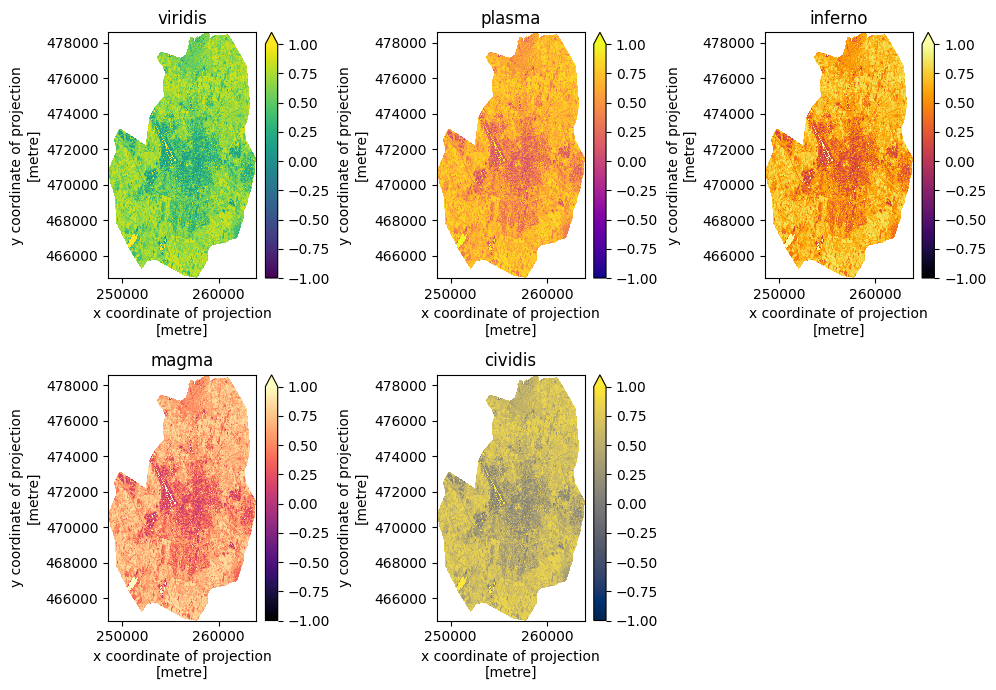

In [22]:
lst =  ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

n = len(lst)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n/ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(n*2, (n*2)-3))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

for _ in range(i+1, n+1):
    fig.delaxes(ax[_])

plt.tight_layout()
plt.show()

### Other Sequential

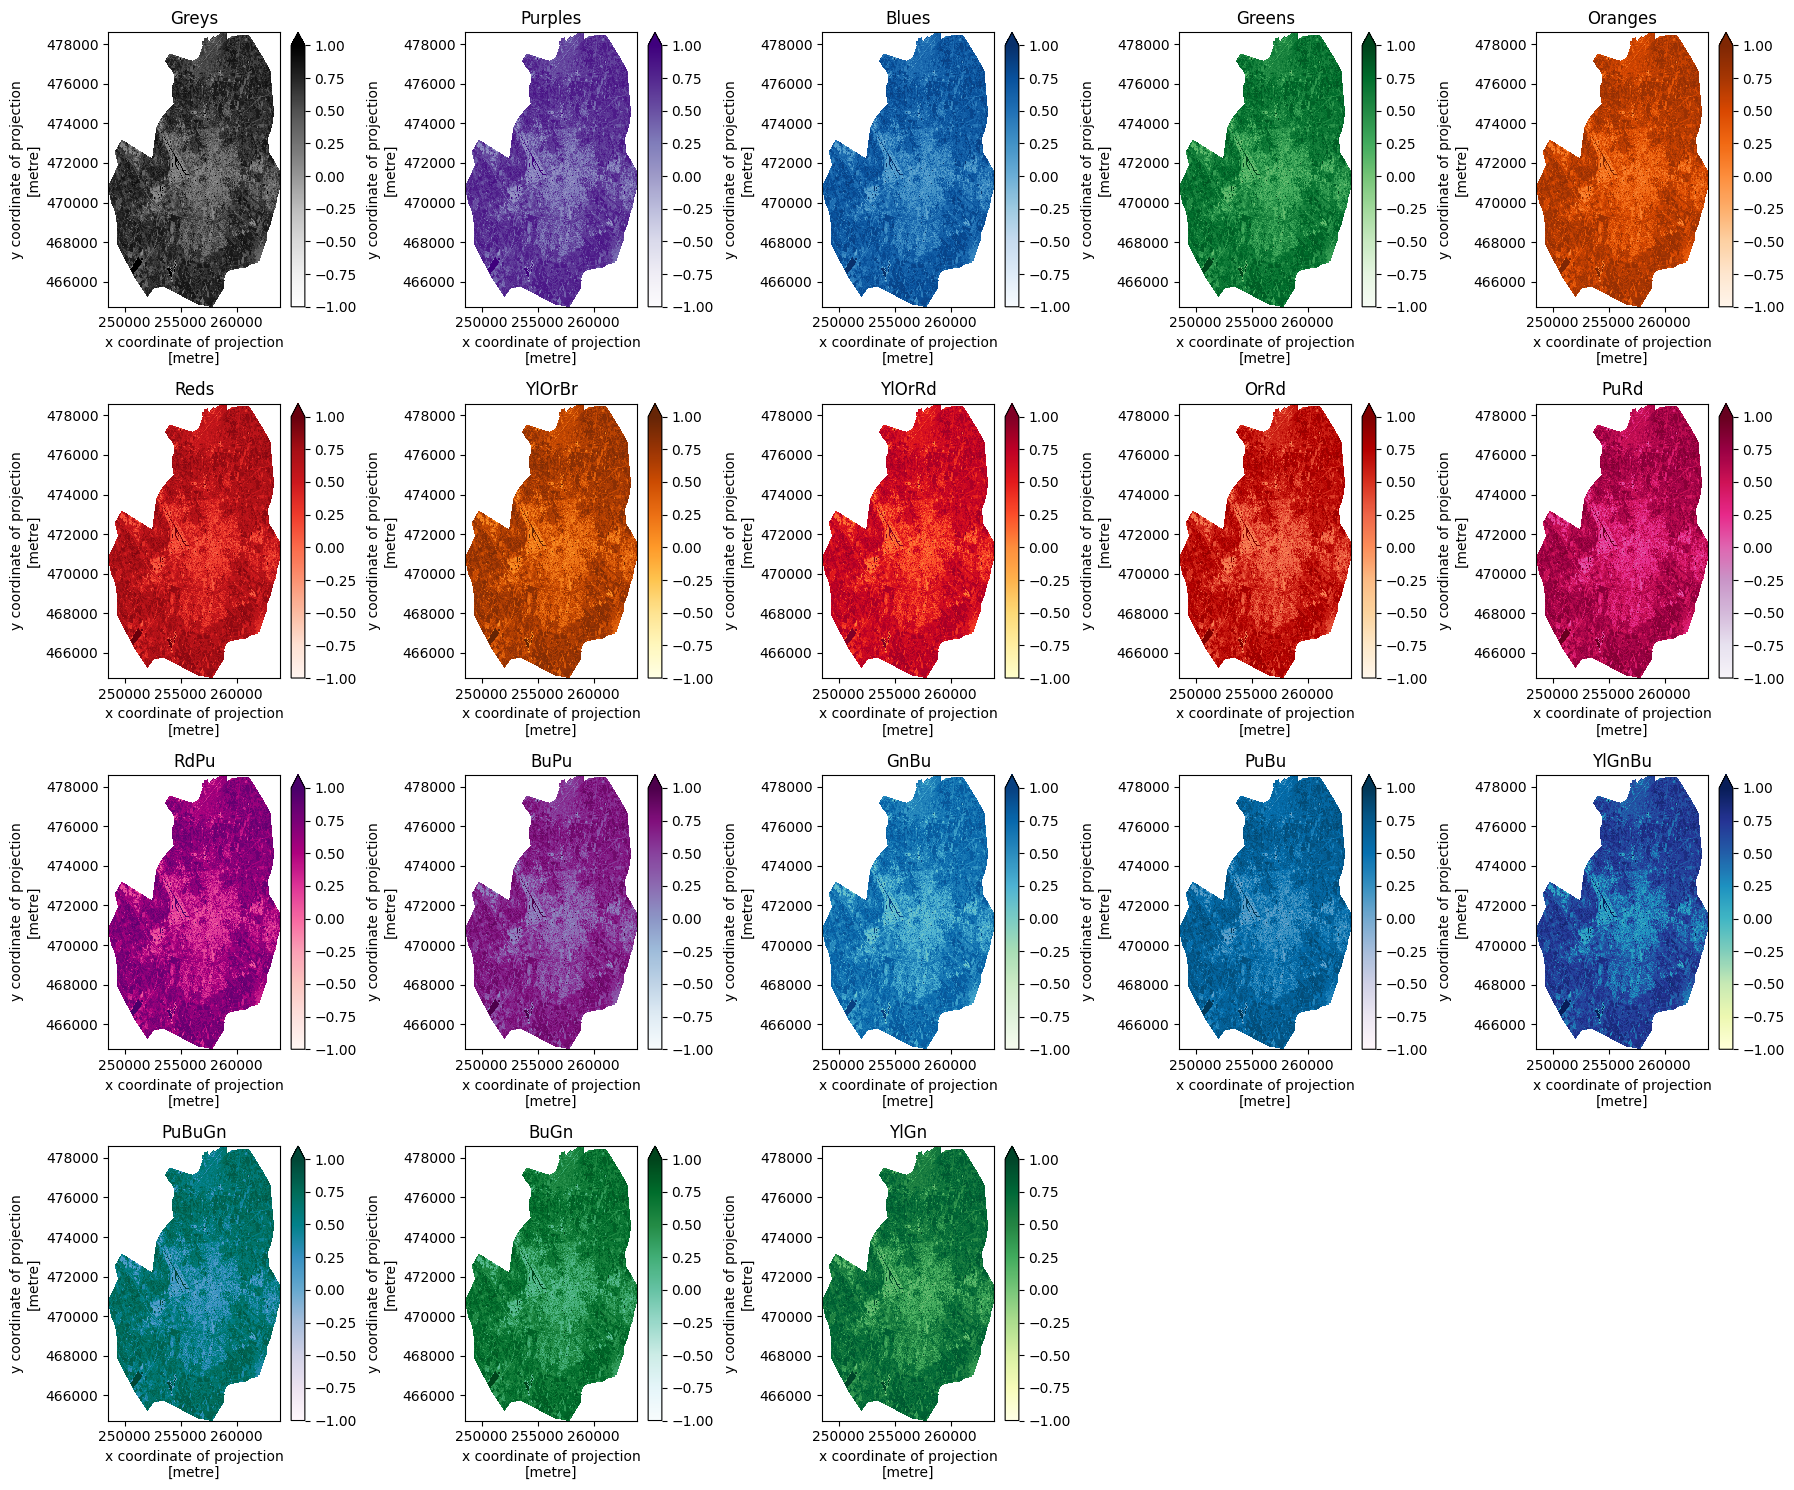

In [23]:
lst =  ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']

n = len(lst)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(n, n-3))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

for _ in range(i+1, n+2):
    fig.delaxes(ax[_])

plt.tight_layout()
plt.show()

### Diverging

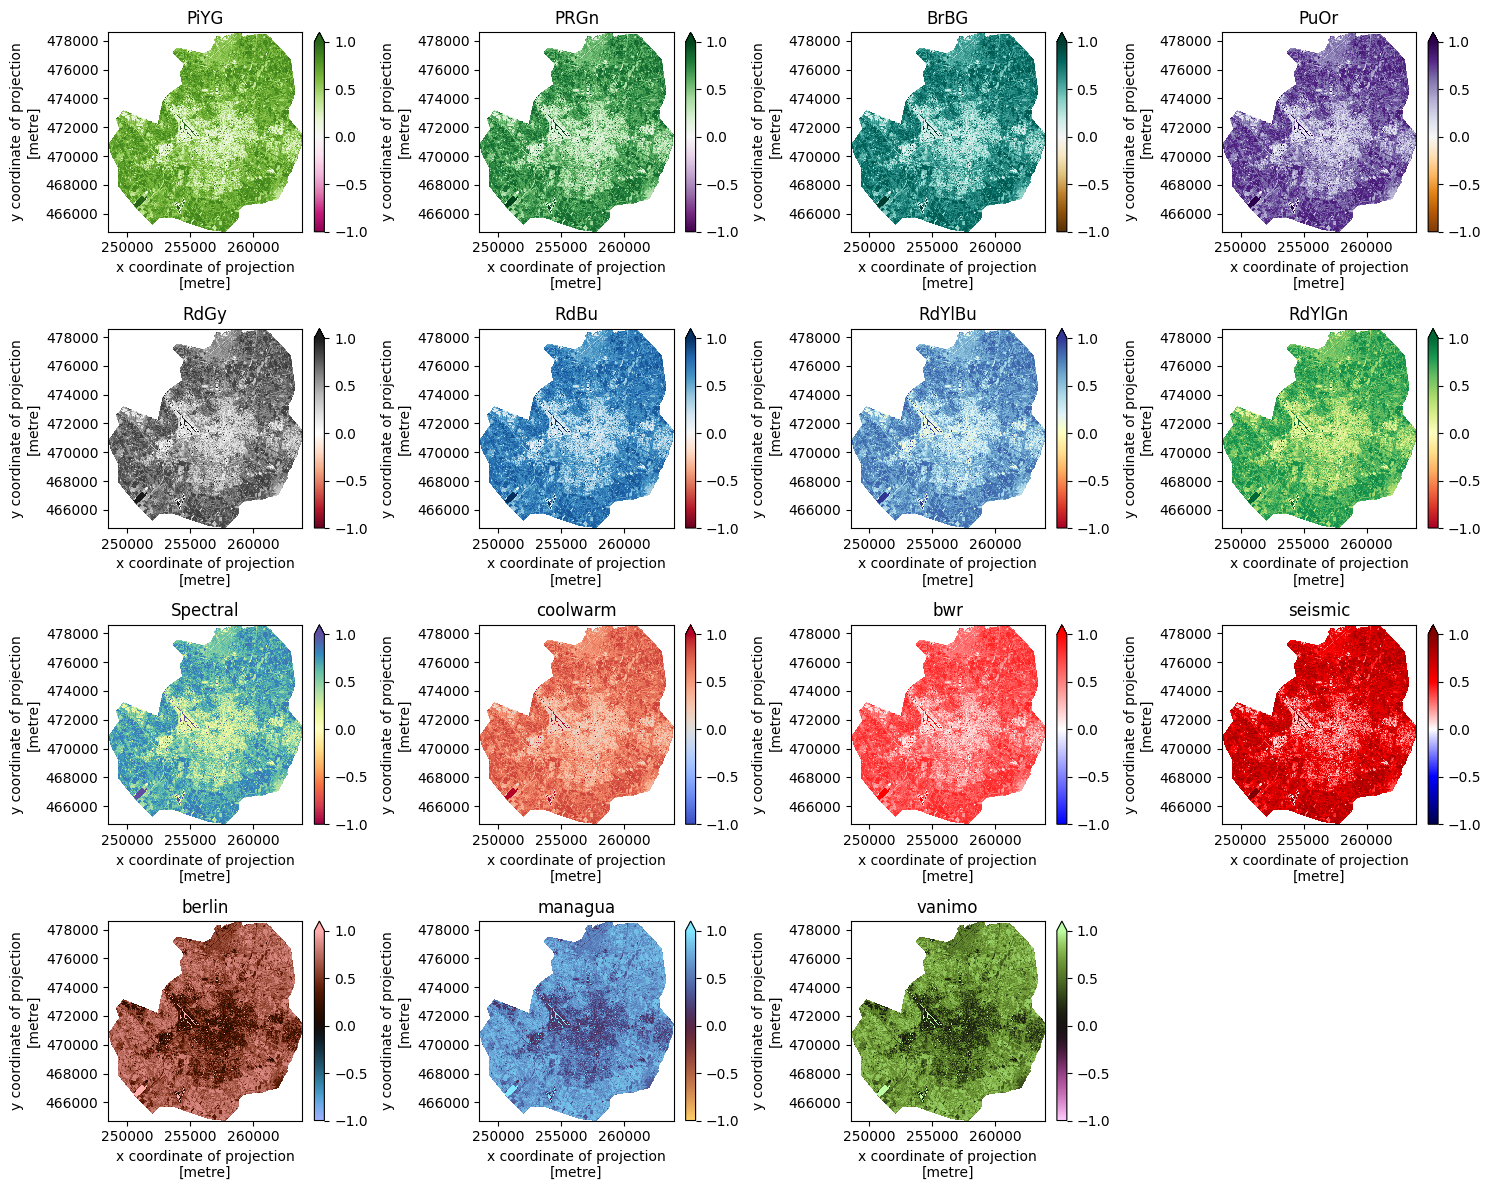

In [24]:
lst = ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
                      'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic',
                      'berlin', 'managua', 'vanimo']

n = len(lst)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n/ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(n,n-3))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

for _ in range(i+1, n+1):
    fig.delaxes(ax[_])

plt.tight_layout()
plt.show()

### Cyclic

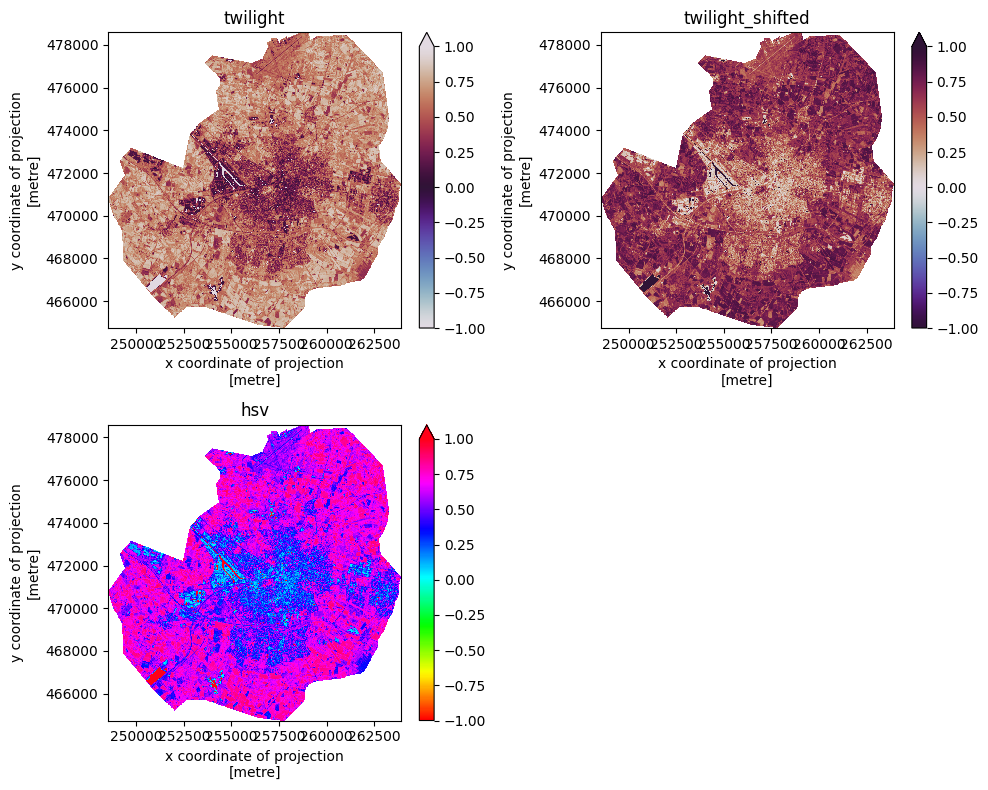

In [25]:
lst = ['twilight', 'twilight_shifted', 'hsv']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

fig.delaxes(ax[i+1])

plt.tight_layout()
plt.show()

### Qualitative

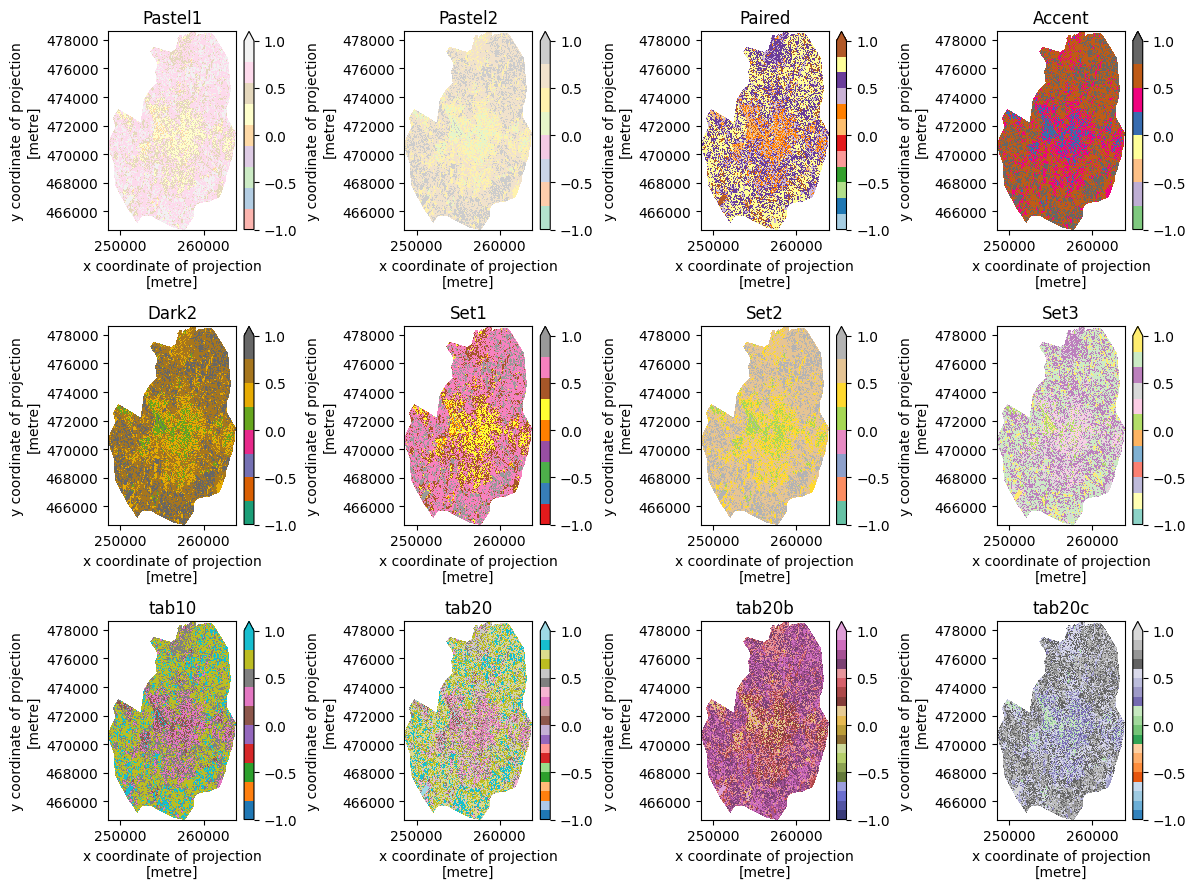

In [26]:
lst =  ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2',
                      'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b',
                      'tab20c']

n = len(lst)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n/ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(n,n-3))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

for _ in range(i+1, n):
    fig.delaxes(ax[_])

plt.tight_layout()
plt.show()

### Miscellaneous

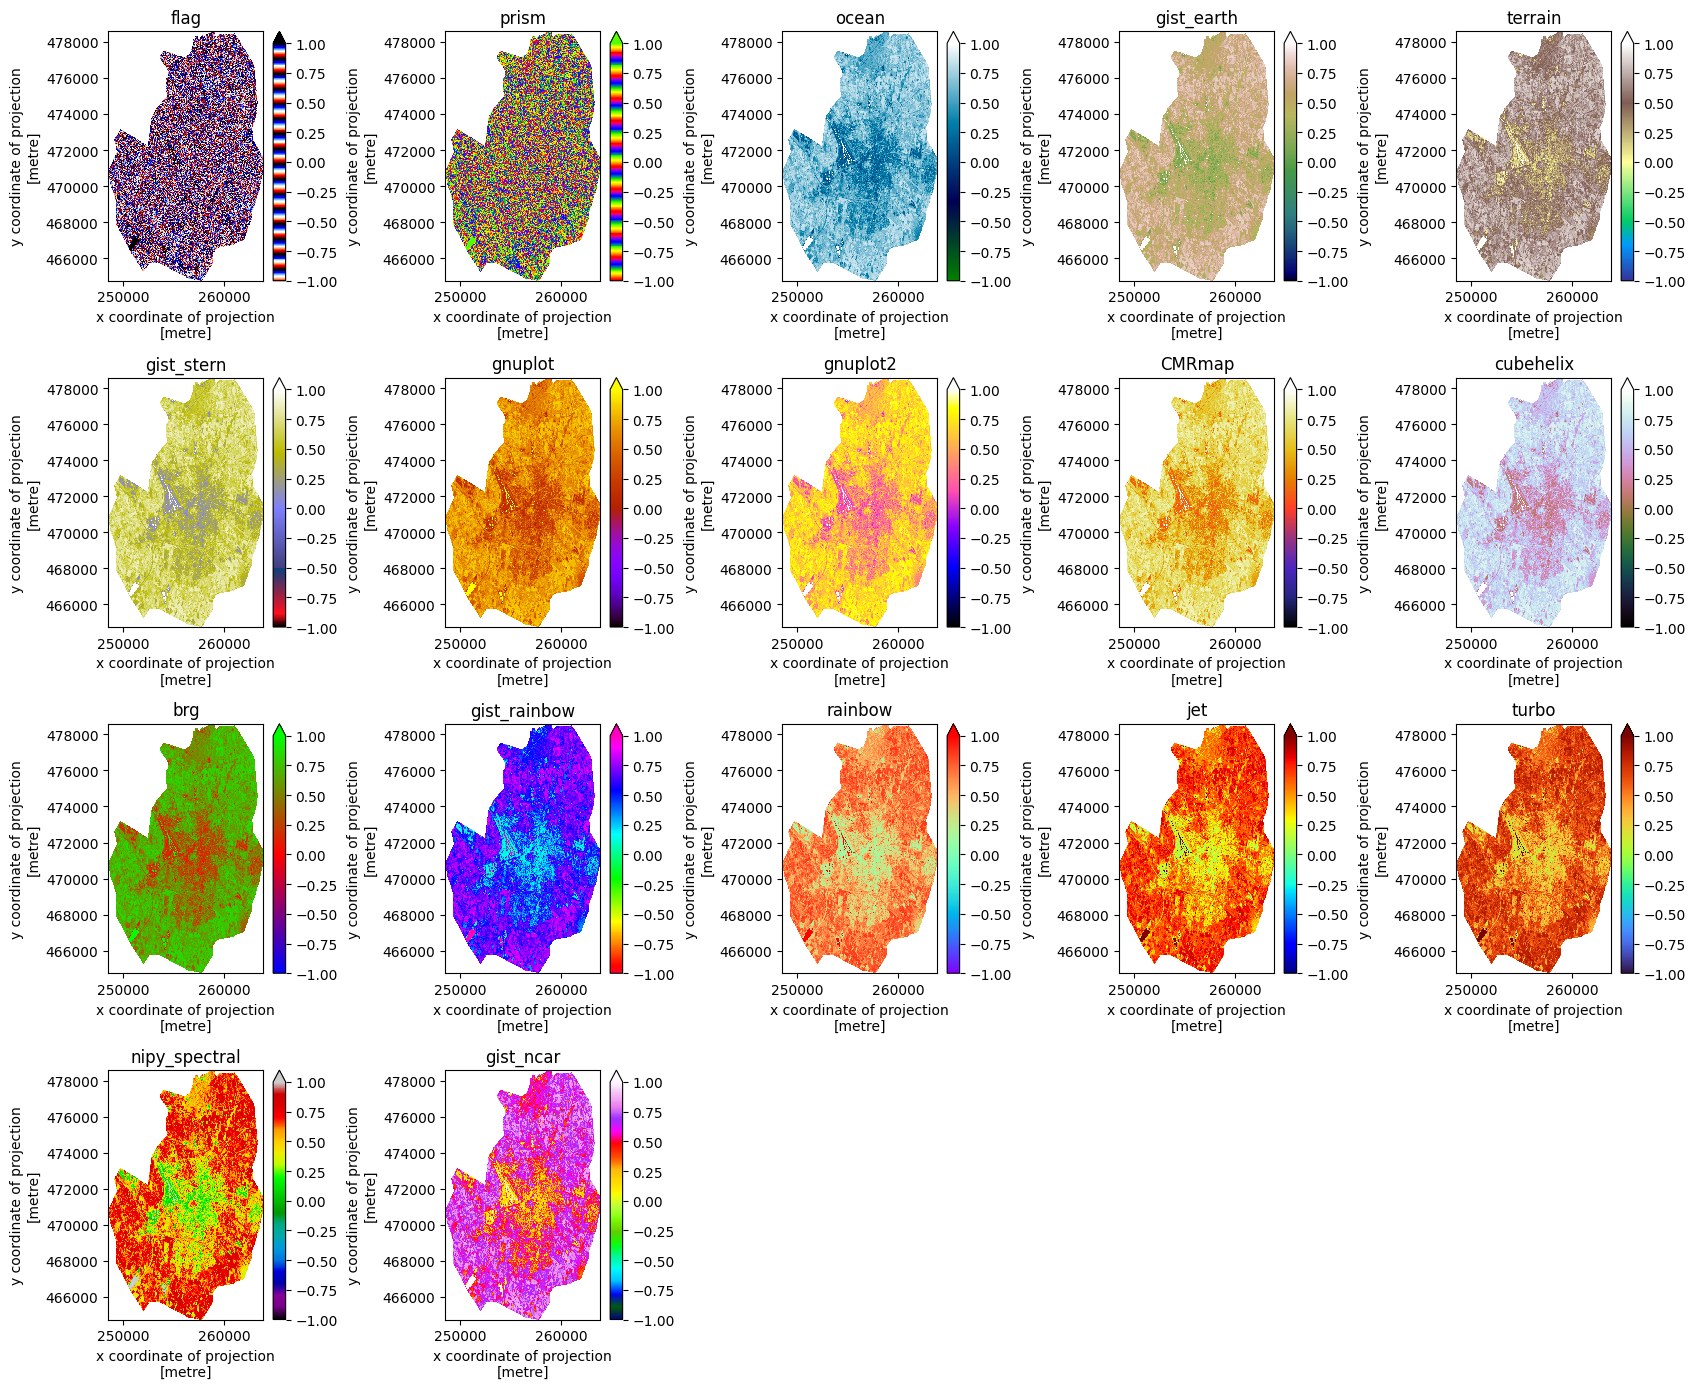

In [27]:
lst = ['flag', 'prism', 'ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet',
                      'turbo', 'nipy_spectral', 'gist_ncar']

n = len(lst)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n/ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(n,n-3))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

for _ in range(i+1, n+3):
    fig.delaxes(ax[_])

plt.tight_layout()
plt.show()

### Selected

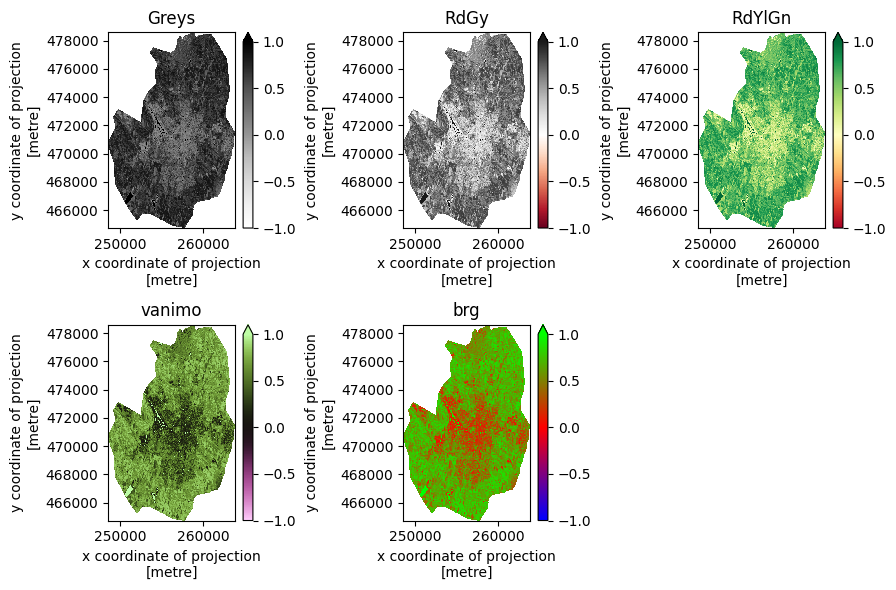

In [28]:
lst =  ['Greys', 'RdGy', 'RdYlGn', 'vanimo', 'brg']

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))
ax = axs.flatten()

for i, cmap in enumerate(lst):
    ndvi.plot.imshow(ax=ax[i], vmin=-1, vmax=1, cmap=cmap)
    ax[i].set_title(lst[i])

fig.delaxes(ax[i+1])

plt.tight_layout()
plt.show()

## Plotting the Final Results

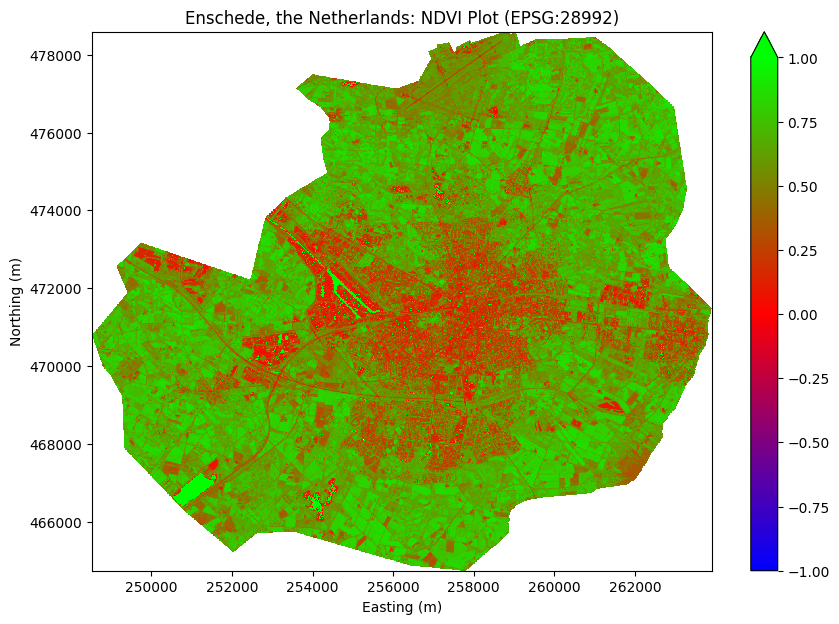

In [29]:
fig, ax = plt.subplots(figsize=(10,7))
ndvi.plot.imshow(ax=ax, vmin=-1, vmax=1, cmap='brg')

ax.set_title(f'Enschede, the Netherlands: NDVI Plot ({enschede.crs})')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()